In [10]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import math
from tqdm import trange
import torch
import warnings
warnings.filterwarnings("ignore")

project_root = r'c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn'
os.chdir(project_root)

# plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams["font.family"] = 'DejaVu Serif' #"serif"
# plt.rcParams.update({
#     'figure.figsize': (4, 3),
#     'font.family': 'DejaVu Serif',
#     'lines.linewidth': 1.2,
#     'lines.markersize': 3.5,
#     'axes.labelsize': 10,
#     'axes.linewidth': 1.2,
#     'xtick.top': False,
#     'ytick.right': False,
#     'xtick.major.width': 1.2,
#     'ytick.major.width': 1.2,
#     'xtick.minor.width': 0.8,
#     'ytick.minor.width': 0.8,
#     'xtick.minor.visible': True,
#     'ytick.minor.visible': True,
#     'xtick.labelsize': 10,
#     'ytick.labelsize': 10,
#     'xtick.direction': 'in',
#     'ytick.direction': 'in',
#     'legend.fontsize': 10,
#     'legend.frameon': False,
#     'figure.dpi': 300,
#     'savefig.dpi': 300,
#     'savefig.bbox': 'tight'
# })


In [11]:
# dyn_p_tensor = torch.load('data/sw_dyn_p.pt')
# condition_nonan = (1-np.isnan(dyn_p_tensor)).numpy().astype(bool)
# print(len(condition_nonan))
# condition4 = condition_nonan & (torch.log(dyn_p_tensor ) > torch.median(torch.log(dyn_p_tensor[condition_nonan]  ))).numpy().astype(bool) 
# print(len(condition4))
# print(sum(condition4)/len(dyn_p_tensor[condition_nonan]))

In [12]:
# dyn_p_tensor = torch.load('data/sw_dyn_p.pt')
# condition_nonan = (1-np.isnan(dyn_p_tensor))
# print(condition_nonan)
# condition4 = condition_nonan & (torch.log(dyn_p_tensor ) <= torch.median(torch.log(dyn_p_tensor[condition_nonan]  )))
# print(condition4)
# print(torch.sum(condition4)/len(dyn_p_tensor[condition_nonan]))

### Dynamic Pressure

In [13]:
df = pd.read_csv('data/solar_wind.csv')
df.columns = df.columns.str.strip()
df['UT'] = df['UT'].str.strip()
df['UT'] = pd.to_datetime(df['UT'],format='%Y-%m-%d/%H:%M:%S')
df['nv**2'] = (df['|v_proton| (km/s)']/1000)**2 * df['n_proton']
df

,UT,n_proton,n_alpha (per cc),|v_proton| (km/s),vx (km/s),vy (km/s),vz (km/s),T_proton (eV),Bx (nT),By (nT),Bz (nT),nv**2
0,2014-11-12 11:55:24,2.189,0.127,425.534,-425.387,10.970,-2.077,8.013,-0.330,1.723,-0.364,0.396382
1,2014-11-12 16:30:53,2.688,0.121,415.434,-415.317,9.747,1.498,5.912,-1.336,2.204,-1.160,0.463910
2,2014-11-13 20:09:35,4.643,0.234,408.254,-407.596,23.084,-1.970,7.044,-0.203,2.749,-0.325,0.773855
3,2014-11-14 00:38:38,4.905,0.244,399.164,-398.338,25.657,-0.912,7.249,-1.011,2.033,1.038,0.781523
4,2014-11-14 14:36:07,4.110,0.251,395.702,-394.333,29.314,14.917,6.811,-1.310,2.982,-1.342,0.643544
...,...,...,...,...,...,...,...,...,...,...,...,...
10306,2025-10-31 08:46:05,2.114,0.113,529.700,-529.216,17.748,14.052,11.643,2.168,-1.614,0.391,0.593151
10307,2025-10-31 12:16:59,1.689,0.101,526.273,-526.224,3.384,6.375,9.533,0.784,-2.607,-0.968,0.467791
10308,2025-10-31 16:01:25,1.819,0.134,503.268,-502.906,18.178,5.742,9.881,2.236,-1.246,-1.777,0.460714
10309,2025-10-31 19:07:03,2.676,0.224,497.505,-495.454,38.792,23.055,8.909,2.977,-0.745,0.395,0.662340


Text(0, 0.5, 'Density')

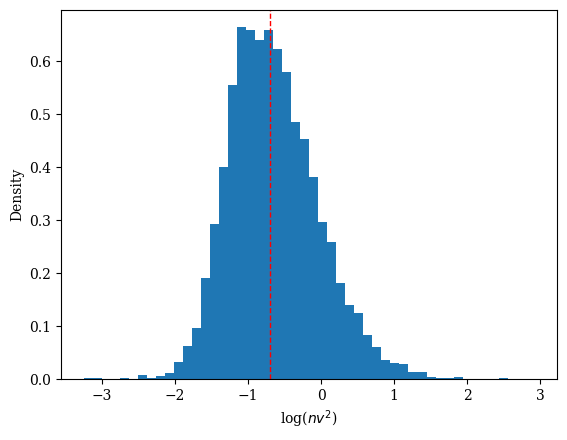

In [14]:
plt.figure()
plt.hist(np.log(df['nv**2']), bins=50, density=True)
plt.axvline(np.log(df['nv**2']).median(), color='r', linestyle='dashed', linewidth=1)
plt.xlabel(r'log($nv^2$)')
plt.ylabel('Density')
# plt.savefig(f'figures/dynamic_pressure/dynamic_pressure_histogram.png',dpi=300)

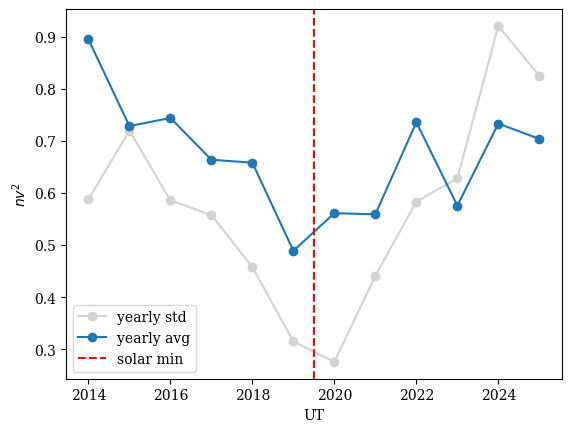

In [15]:
plt.figure()
years = np.arange(df['UT'].dt.year.min(), df['UT'].dt.year.max() + 1)
yearly_avg = []
yearly_std = []
for year in years:
    yearly_avg.append(df[df['UT'].dt.year == year]['nv**2'].mean())
    yearly_std.append(df[df['UT'].dt.year == year]['nv**2'].std())
plt.plot(years, yearly_std, marker='o', label = 'yearly std',color='lightgrey')
plt.plot(years, yearly_avg, marker='o', label='yearly avg')
# plt.errorbar(years, yearly_avg, yerr=yearly_std, fmt='o', color='blue', ecolor='lightgray', capsize=5)
# plt.scatter(years[np.argmin(yearly_avg)], min(yearly_avg), c='red', s=100, marker='X')
# plt.text(years[np.argmin(yearly_avg)]+0.5, min(yearly_avg), 'Solar Minimum', fontsize=12, color='red')
plt.axvline(x=2019.5, color='red',linestyle='--',label='solar min')
plt.xlabel('UT')
plt.ylabel(r'$nv^2$')
# put legend outside of the plot
plt.legend()
# plt.savefig(f'figures/dynamic_pressure/dynamic_pressure_over_time.png',dpi=300)

### Associate MAVEN MAG to dynamic pressure (closest match)

In [ ]:
compute = 1

if compute:


    mav_time = pd.read_parquet('data/MAVEN_MSO_data.parquet', columns=['time'])


    results = []
    chunk_size = 100000
    num_chunks = math.ceil(len(mav_time) / chunk_size)

    pbar = trange(num_chunks, desc='Joining MAVEN MAG and dyn P on time')


    for i in pbar:
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, len(mav_time))
        mav_chunk = mav_time.iloc[start_idx:end_idx].sort_values('time')

        merged = pd.merge_asof(
            left=mav_chunk,
            right=df,#.sort_values('UT'),
            left_on='time',
            right_on='UT',
            direction='nearest',
            tolerance=pd.Timedelta(days=1),
        )
        results.append(merged)
        
    dyn_p = pd.concat(results)



In [17]:
# dyn_p_tensor = torch.tensor(dyn_p['nv**2'].to_numpy(),dtype=torch.float32)
# torch.save(dyn_p_tensor,'data/sw_dyn_p.pt')

# dyn_p_tensor = torch.load('data/sw_dyn_p.pt')
# print(dyn_p_tensor)


# # count number of nan:
# num_nan = np.isnan(dyn_p_tensor).sum()
# print(100*num_nan/len(dyn_p_tensor))



In [18]:
# number of nan per year:
if compute:
    dyn_p['year'] = dyn_p['time'].dt.year
    nan_per_year = dyn_p.groupby('year')['nv**2'].apply(lambda x: np.isnan(x).sum())
    print(nan_per_year)

    plt.figure()
    plt.plot(nan_per_year.index, nan_per_year.values, marker='o')
    plt.xlabel('Year')
    plt.ylabel('Number of NaN values in $nv^2$')

### Data residuals vs dynamic pressure

In [19]:
day_side = True

prediction_df = pd.read_csv('predictions/data/PINN_MSO_ensemble_models_1to30_all_year_data_650km.csv',usecols=['idx','Bx','By','Bz'])
condition = prediction_df.idx

observation_mso = torch.load('data/observation_mso.pt')[condition]
crustal_field_mso = torch.load('data/crustal_field_mso.pt')[condition]
target = observation_mso - crustal_field_mso
B_obs = torch.sqrt(target[:,0]**2 + target[:,1]**2 + target[:,2]**2).numpy()
del observation_mso, target

B_iono_scalar = np.sqrt(prediction_df['Bx'].values**2 + prediction_df['By'].values**2 + prediction_df['Bz'].values**2)
res = B_obs-B_iono_scalar
del prediction_df

dyn_p_tensor = torch.load('data/sw_dyn_p.pt')[condition]

# sample only dayside
if day_side:
    input_sph = torch.load('data/position_mso_spherical.pt')[condition]
    deg_max = 90
    condition2 =  (input_sph[:,2] >= -deg_max) & (input_sph[:,2] <= deg_max)
    res = res[condition2]
    dyn_p_tensor = dyn_p_tensor[condition2]

# remove nan values of dyn_p_tensor
condition3 = (1-np.isnan(dyn_p_tensor).numpy()).astype(bool)
res = res[condition3]
dyn_p_tensor = dyn_p_tensor[condition3]



In [20]:
# day_side=True
# if day_side:
#     input_sph = torch.load('data/position_mso_spherical.pt')[condition]
#     input_sph = input_sph[condition3]
#     deg_max = 90
#     condition2 =  (input_sph[:,2] >= -deg_max) & (input_sph[:,2] <= deg_max)
#     res = res[condition2]
#     dyn_p_tensor = dyn_p_tensor[condition2]

In [21]:
# print(len(bin_idx))
print(len(dyn_p_tensor))
print(len(res))
print(len(condition3))

8516293
8516293
19648647


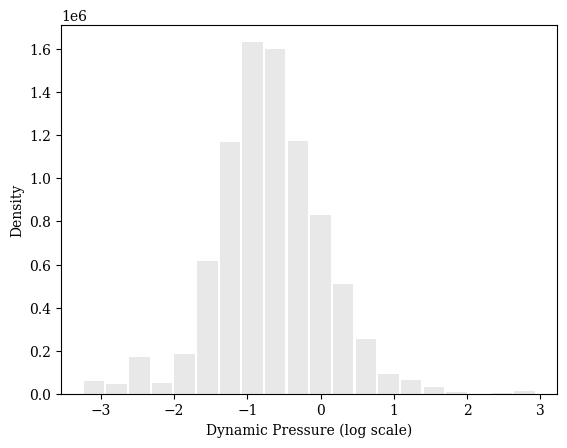

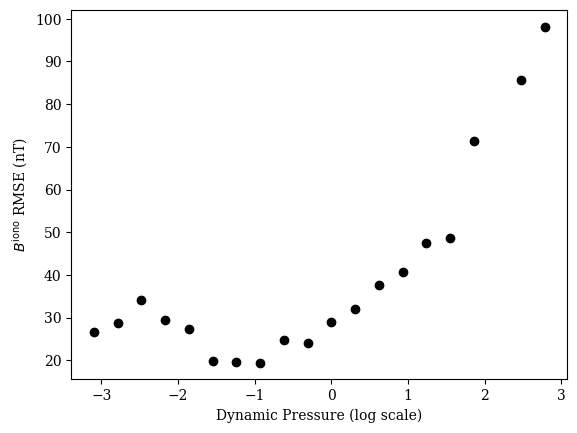

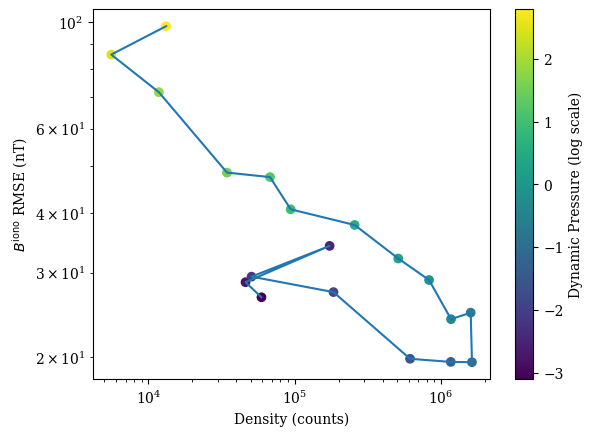

In [22]:
log_dyn_p = torch.log(dyn_p_tensor)
dyn_p_bins = np.linspace(torch.min(log_dyn_p), torch.max(log_dyn_p), 20)

step = dyn_p_bins[1]-dyn_p_bins[0]
# print(dyn_p_bins)

# Assign each value to a bin
bin_idx = np.digitize(log_dyn_p, dyn_p_bins) - 1
    
# # # Keep only valid bins
# valid = (bin_idx < len(dyn_p_bins)-1)
# print(f"Valid bins: {np.sum(valid)}, Total samples: {len(dyn_p_tensor)}")
# bin_idx = bin_idx[valid]
# res_valid = res[valid]

# Compute mean square per bin
sum_sq = np.bincount(bin_idx, weights=res**2, minlength=len(dyn_p_bins)-1)
count = np.bincount(bin_idx, minlength=len(dyn_p_bins)-1)
rmses = np.sqrt(sum_sq / count)

# remove nan from rmse and count (happens when count is 0, i.e. no samples in the bin)
rmses_nonan = rmses[~np.isnan(rmses)]
count_nonan = count[~np.isnan(rmses)]
dyn_p_bins_nonan = dyn_p_bins[~np.isnan(rmses)]

# number of samples per bin:
plt.figure()
plt.bar(dyn_p_bins + step/2, count, width=step*0.9, color='lightgray', alpha=0.5)
plt.xlabel('Dynamic Pressure (log scale)')
plt.ylabel('Density')
# plt.yscale('log')
# plt.savefig(f'figures/dynamic_pressure/dyn_p_density.png',dpi=300)


# Plot RMSE
plt.figure()
plt.scatter(dyn_p_bins + step/2, rmses, color='k')
plt.xlabel('Dynamic Pressure (log scale)')
plt.ylabel(r'$B^\text{iono}$ RMSE (nT)')
add_str = '_dayside' if day_side else ''
# plt.savefig(f'figures/dynamic_pressure/RMSEvsdynamic_pressure{add_str}_new.png',dpi=300)


# density and rmse correlation, color by dynamic pressure
plt.figure()
plt.scatter(count_nonan, rmses_nonan, cmap=plt.get_cmap('viridis'), c=dyn_p_bins_nonan+ step/2)
plt.plot(count_nonan, rmses_nonan)
plt.xlabel('Density (counts)')
plt.ylabel(r'$B^\text{iono}$ RMSE (nT)')
plt.xscale('log')
plt.yscale('log')
plt.colorbar(label='Dynamic Pressure (log scale)')
# plt.savefig(f'figures/dynamic_pressure/RMSEvsDensityvsDynP{add_str}.png',dpi=300)


Text(0, 0.5, '$B^\\text{iono}$ RMSE (nT)')

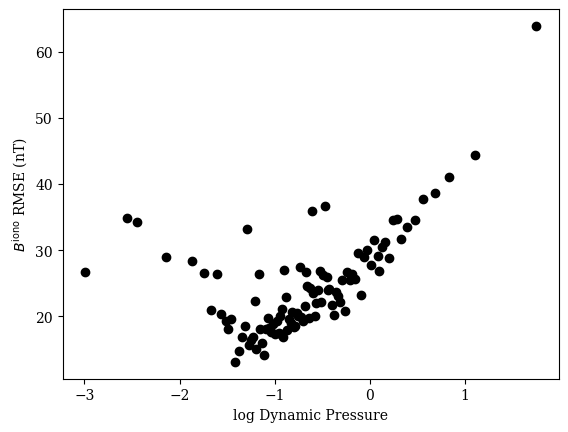

In [23]:
# Sort by log_dyn_p

log_dyn_p_np = torch.log(dyn_p_tensor).numpy()
sort_idx = np.argsort(log_dyn_p_np)
log_dyn_p_sorted = log_dyn_p_np[sort_idx]
res_sorted = res[sort_idx]

# Number of bins
n_bins = 100
N = len(log_dyn_p_sorted)

# Split into equal-sized bins
bins = np.array_split(np.arange(N), n_bins)

rmses = []
bin_centers = []
counts = []

for b in bins:
    vals = res_sorted[b]
    rmses.append(np.sqrt(np.mean(vals**2)))
    bin_centers.append(np.mean(log_dyn_p_sorted[b]))
    counts.append(len(b))


# Plot
plt.figure()
plt.scatter(bin_centers, rmses, color='k')
plt.xlabel('log Dynamic Pressure')
plt.ylabel(r'$B^\text{iono}$ RMSE (nT)')
# plt.xscale('log')
# plt.show()